# Imports

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

# Loading env variables

In [2]:
load_dotenv()

True

# Define LLM

In [3]:
model = ChatGroq(
    model="qwen/qwen3-32b"    # other params...
)

# Define State

In [4]:
class BlogState(TypedDict):
     
     title : str
     outline : str
     content : str

# Creating Nodes

In [5]:
def create_oultine(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    Prompt = f'write a detailed blog on the title - {title} using the following outline \n {outline}'

    content = model.invoke(Prompt).content

    state['content'] = content

    return state

# Define and Compile Graph

In [7]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_oultine',create_oultine)
graph.add_node('create_blog',create_blog)

#edges
graph.add_edge(START,'create_oultine')
graph.add_edge('create_oultine','create_blog')
graph.add_edge('create_blog',END)

workflow = graph.compile()


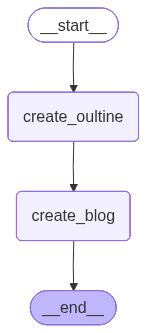

In [8]:
workflow

In [9]:
intial_state = {'title' : 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '<think>\nOkay, the user wants a detailed blog outline on the Rise of AI in India. Let me start by breaking down the key areas. First, I should define AI and set the context for why India is important in this field. Maybe start with an introduction that highlights India\'s growing role in AI.\n\nNext, I need historical context. When did AI start in India? Maybe touch on early research and education, like the 1980s with IITs and AI labs. Then move to recent developments, like government initiatives such as NITI Aayog\'s AI strategy and the National AI Mission.\n\nCurrent landscape is important. I should mention key sectors adopting AI, like healthcare, agriculture, and finance. Also, talk about major companies and startups in India contributing to AI. For example, TCS, Wipro, and startups like SigTuple and Niki.ai.\n\nGovernment policies and funding are crucial. The Digital India initiative and Atmanirbhar Bharat. Also, mention AI policy frame

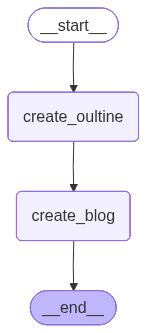

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())